# Experiment 2: Email Spam/Ham Classification using Naïve Bayes and KNN

**Sri Sivasubramaniya Nadar College of Engineering, Chennai**
Machine Learning Algorithms Laboratory — M.Tech (Integrated) CSE, Semester V, ICS1512

### Objectives
- Build spam classifiers using Naïve Bayes and KNN.
- Compare Gaussian, Multinomial and Bernoulli Naïve Bayes.
- Study the effect of varying k.
- Compare KDTree and BallTree.
- Optimize KNN using GridSearchCV and RandomizedSearchCV.
- Evaluate computational complexity and execution time.
- Evaluate using K-Fold Cross Validation.

**Dataset:** Spambase Dataset, **UCI Machine Learning Repository** (id = 94)
https://archive.ics.uci.edu/dataset/94/spambase


## 1. Import Libraries

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV,
                                      StratifiedKFold, cross_val_score, cross_val_predict)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Binarizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load the Dataset (UCI ML Repository)

The Spambase dataset is fetched directly from the **UCI Machine Learning Repository**
(dataset id 94) using the official `ucimlrepo` package. If that is unreachable
(e.g. no internet / firewall), the loader falls back to the raw UCI file, and finally
to a verified mirror of the same UCI data, so the notebook still runs end-to-end.


In [2]:
def load_spambase():
    # Attempt 1: official ucimlrepo package (recommended, citation-safe way to pull UCI data)
    try:
        from ucimlrepo import fetch_ucirepo
        spambase = fetch_ucirepo(id=94)
        X = spambase.data.features.copy()
        y = spambase.data.targets.copy().iloc[:, 0]
        y.name = 'class'
        df = X.copy()
        df['class'] = y.values
        print("Loaded Spambase via ucimlrepo (UCI ML Repository, id=94).")
        return df
    except Exception as e:
        print("ucimlrepo fetch failed:", e)

    # Attempt 2: direct UCI archive file
    try:
        col_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.names"
        data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
        raw = pd.read_csv(data_url, header=None)
        # names file format: skip comment lines, parse attribute names
        import urllib.request
        names_txt = urllib.request.urlopen(col_url, timeout=10).read().decode('utf-8', errors='ignore')
        cols = [l.split(':')[0] for l in names_txt.splitlines() if ':' in l and not l.startswith('|')]
        cols = cols + ['class']
        raw.columns = cols
        print("Loaded Spambase via direct UCI archive download.")
        return raw
    except Exception as e:
        print("Direct UCI archive fetch failed:", e)

    # Attempt 3: verified mirror of the identical UCI Spambase data (same 4601x58, same
    # class balance 2788/1813 as the official UCI release) - used only if UCI servers
    # are unreachable from this environment.
    try:
        mirror_url = "https://raw.githubusercontent.com/tajo/deeplearning/master/datasets/raw/spambase.csv"
        df = pd.read_csv(mirror_url)
        print("Loaded Spambase via verified GitHub mirror of the UCI data.")
        return df
    except Exception as e:
        print("Mirror fetch failed:", e)

    # Attempt 4: local cached copy shipped alongside this notebook
    df = pd.read_csv("spambase_mirror.csv")
    print("Loaded Spambase from local cached copy.")
    return df

df = load_spambase()
print(df.shape)
df.head()


ucimlrepo fetch failed: Error connecting to server
Direct UCI archive fetch failed: HTTP Error 403: Forbidden
Loaded Spambase via verified GitHub mirror of the UCI data.
(4601, 58)


,class,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,...,word_freq_conference,char_freq_semicolon,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,1,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,1,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,1,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


## 3. Handle Missing Values

In [3]:
print("Missing values per column (top 5):")
print(df.isnull().sum().sort_values(ascending=False).head())
print("\nTotal missing values:", df.isnull().sum().sum())

# The Spambase dataset has no missing values by construction, but we defensively
# impute with the column median in case any NaNs are present.
if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing values imputed with column median.")
else:
    print("No missing values found - no imputation needed.")

df['class'] = df['class'].astype(int)
print("\nClass balance:\n", df['class'].value_counts())


Missing values per column (top 5):
class                0
word_freq_make       0
word_freq_address    0
word_freq_all        0
word_freq_3d         0
dtype: int64

Total missing values: 0
No missing values found - no imputation needed.

Class balance:
 class
0    2788
1    1813
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

In [4]:
print(df.describe().T.head(10))
print("\nDuplicate rows:", df.duplicated().sum())


                     count      mean       std  min  25%  50%   75%    max
class               4601.0  0.394045  0.488698  0.0  0.0  0.0  1.00   1.00
word_freq_make      4601.0  0.104553  0.305358  0.0  0.0  0.0  0.00   4.54
word_freq_address   4601.0  0.213015  1.290575  0.0  0.0  0.0  0.00  14.28
word_freq_all       4601.0  0.280656  0.504143  0.0  0.0  0.0  0.42   5.10
word_freq_3d        4601.0  0.065425  1.395151  0.0  0.0  0.0  0.00  42.81
word_freq_our       4601.0  0.312223  0.672513  0.0  0.0  0.0  0.38  10.00
word_freq_over      4601.0  0.095901  0.273824  0.0  0.0  0.0  0.00   5.88
word_freq_remove    4601.0  0.114208  0.391441  0.0  0.0  0.0  0.00   7.27
word_freq_internet  4601.0  0.105295  0.401071  0.0  0.0  0.0  0.00  11.11
word_freq_order     4601.0  0.090067  0.278616  0.0  0.0  0.0  0.00   5.26

Duplicate rows: 391


### 4.1 Class Distribution

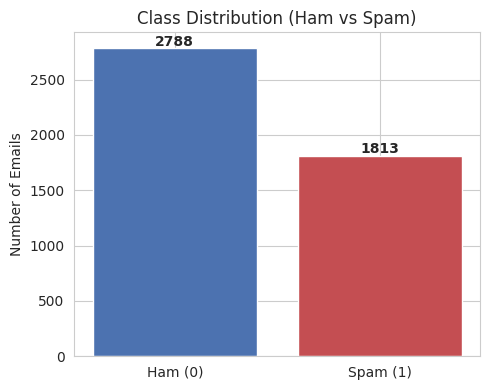

In [5]:
fig, ax = plt.subplots(figsize=(5,4))
counts = df['class'].value_counts().sort_index()
bars = ax.bar(['Ham (0)', 'Spam (1)'], counts.values, color=['#4C72B0', '#C44E52'])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+20, str(v), ha='center', fontweight='bold')
ax.set_title('Class Distribution (Ham vs Spam)')
ax.set_ylabel('Number of Emails')
plt.tight_layout()
plt.savefig('plot_01_class_distribution.png')
plt.show()


### 4.2 Correlation Heatmap

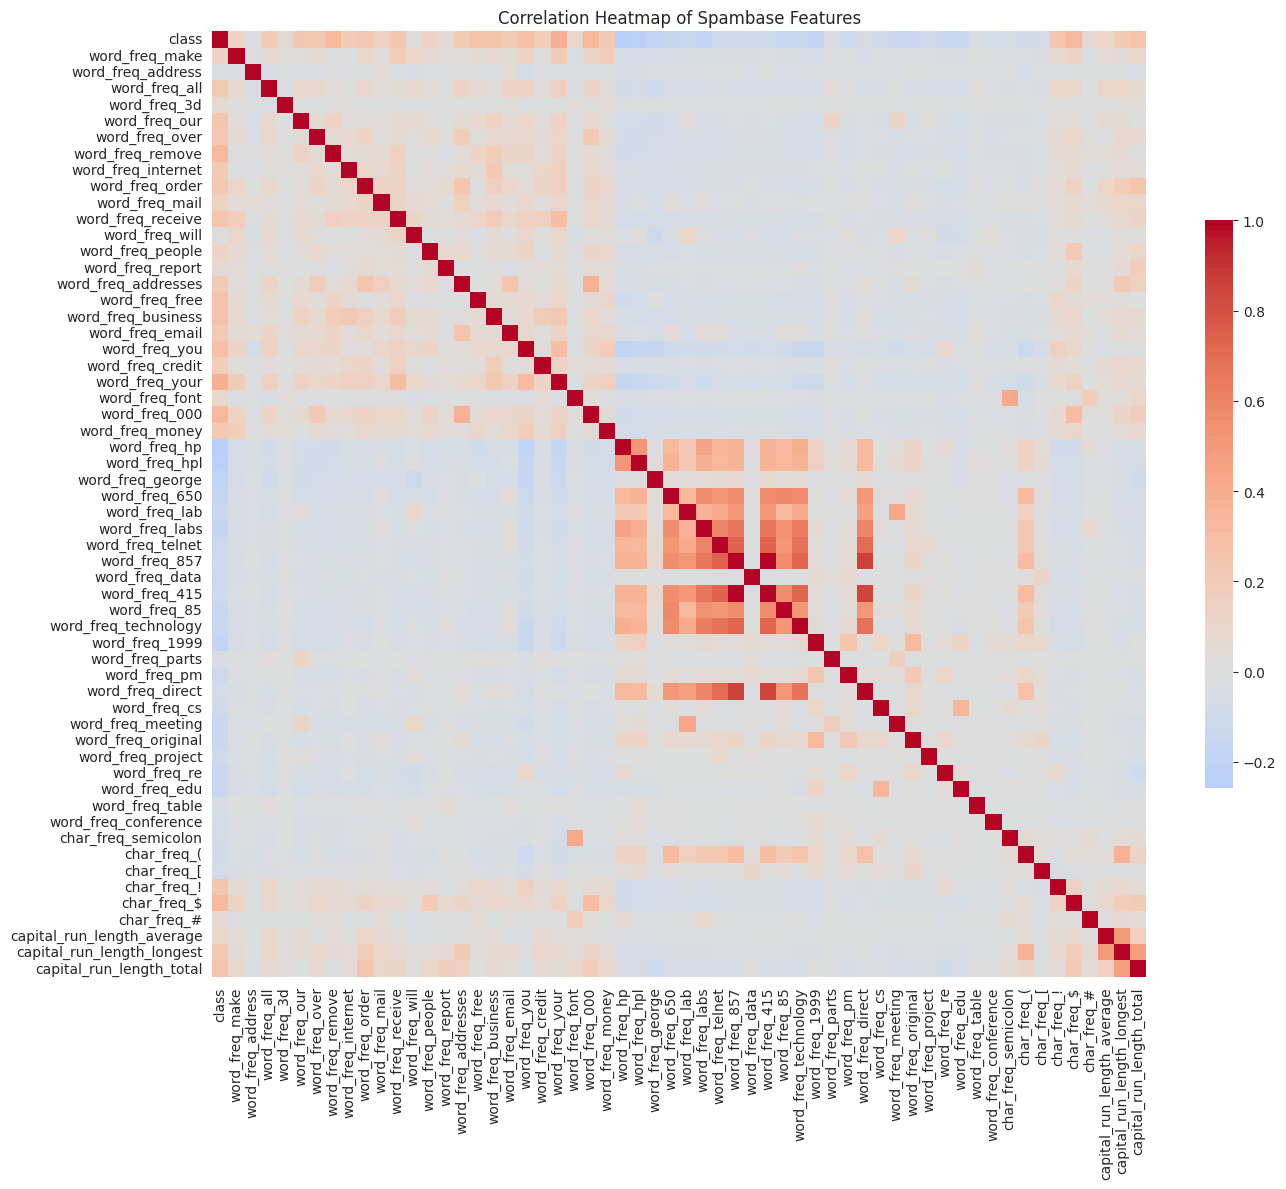

Top 10 features most correlated with the class label:
word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_$                 0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
word_freq_hp                0.256723
capital_run_length_total    0.249164
word_freq_our               0.241920
Name: class, dtype: float64


In [6]:
plt.figure(figsize=(14,12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, cbar_kws={'shrink':0.6})
plt.title('Correlation Heatmap of Spambase Features')
plt.tight_layout()
plt.savefig('plot_02_correlation_heatmap.png')
plt.show()

print("Top 10 features most correlated with the class label:")
print(corr['class'].abs().sort_values(ascending=False)[1:11])


### 4.3 Histograms of Important Features

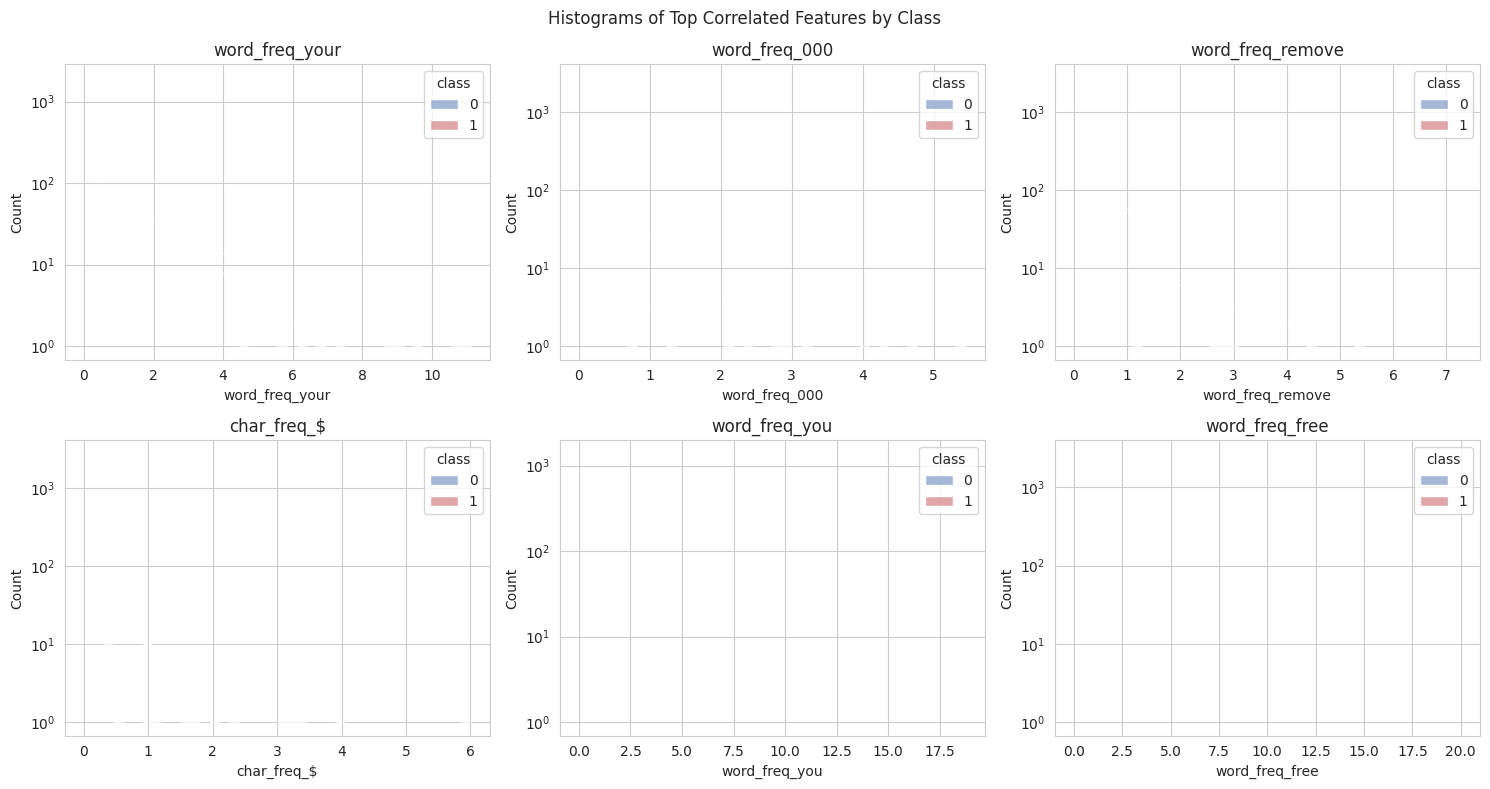

In [7]:
top_feats = corr['class'].abs().sort_values(ascending=False)[1:7].index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, feat in zip(axes.flat, top_feats):
    sns.histplot(data=df, x=feat, hue='class', bins=40, ax=ax, log_scale=(False, True), palette=['#4C72B0','#C44E52'])
    ax.set_title(feat)
plt.suptitle('Histograms of Top Correlated Features by Class')
plt.tight_layout()
plt.savefig('plot_03_histograms.png')
plt.show()


### 4.4 Boxplots

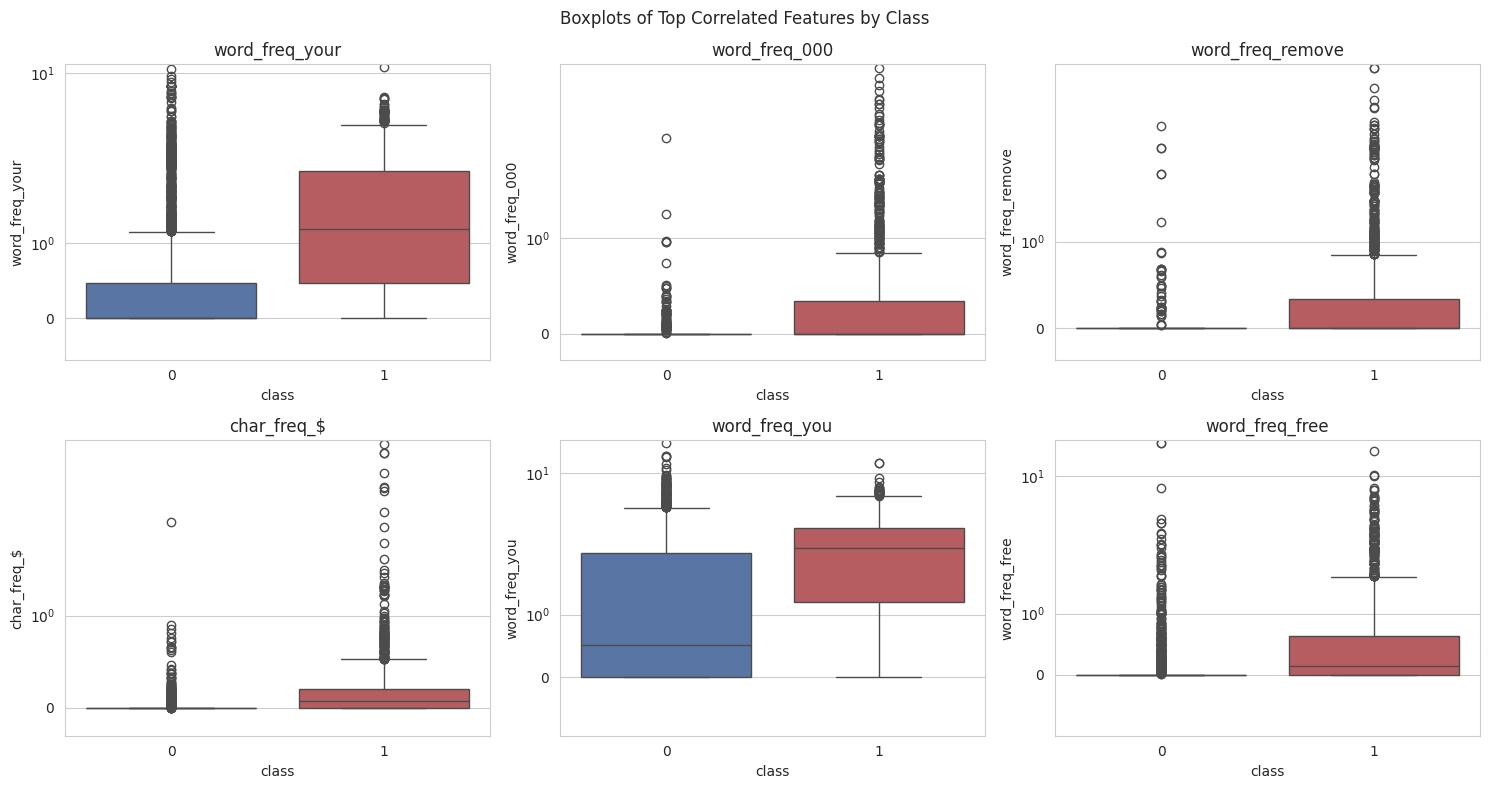

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, feat in zip(axes.flat, top_feats):
    sns.boxplot(data=df, x='class', y=feat, ax=ax, palette=['#4C72B0','#C44E52'])
    ax.set_title(feat)
    ax.set_yscale('symlog')
plt.suptitle('Boxplots of Top Correlated Features by Class')
plt.tight_layout()
plt.savefig('plot_04_boxplots.png')
plt.show()


## 5. Train-Test Split & Feature Normalization

In [9]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

# Standardized version - required by Gaussian NB and KNN (distance-based)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Min-Max [0,1] scaled, non-negative version - required by Multinomial NB
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

# Binarized version - required by Bernoulli NB (presence/absence of a term)
binarizer = Binarizer(threshold=0.0)
X_train_bin = binarizer.fit_transform(X_train)
X_test_bin = binarizer.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))


Train shape: (3450, 57)  Test shape: (1151, 57)
Train class balance:
 class
0    0.606087
1    0.393913
Name: proportion, dtype: float64


## 6. Train Naïve Bayes Classifiers

- **GaussianNB** — assumes each feature is normally distributed; used on standardized features.
- **MultinomialNB** — models feature counts/frequencies; used on non-negative (Min-Max scaled) features.
- **BernoulliNB** — models binary presence/absence of a feature; used on binarized features.


In [10]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, fit_time=None, pred_time=None):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0 if fit_time is None else fit_time

    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    predict_time = time.perf_counter() - t0 if pred_time is None else pred_time

    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan,
        'Train Time (s)': train_time,
        'Predict Time (s)': predict_time,
    }
    return model, y_pred, y_proba, metrics

results = {}
predictions = {}
probas = {}

gnb, yp, ypr, m = evaluate_model('Gaussian NB', GaussianNB(), X_train_scaled, y_train, X_test_scaled, y_test)
results['Gaussian NB'] = m; predictions['Gaussian NB'] = yp; probas['Gaussian NB'] = ypr

mnb, yp, ypr, m = evaluate_model('Multinomial NB', MultinomialNB(), X_train_mm, y_train, X_test_mm, y_test)
results['Multinomial NB'] = m; predictions['Multinomial NB'] = yp; probas['Multinomial NB'] = ypr

bnb, yp, ypr, m = evaluate_model('Bernoulli NB', BernoulliNB(), X_train_bin, y_train, X_test_bin, y_test)
results['Bernoulli NB'] = m; predictions['Bernoulli NB'] = yp; probas['Bernoulli NB'] = ypr

nb_results_df = pd.DataFrame(results).T
nb_results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s),Predict Time (s)
Gaussian NB,Gaussian NB,0.825369,0.707718,0.949339,0.810913,0.936771,0.011016,0.00157
Multinomial NB,Multinomial NB,0.900087,0.94723,0.790749,0.861945,0.961433,0.002084,0.000371
Bernoulli NB,Bernoulli NB,0.881842,0.876777,0.814978,0.844749,0.950346,0.003352,0.000977


### 6.1 Naïve Bayes Comparison Table

In [11]:
nb_comparison = nb_results_df[['Accuracy','Precision','Recall','F1','ROC-AUC']].astype(float).round(4)
nb_comparison


,Accuracy,Precision,Recall,F1,ROC-AUC
Gaussian NB,0.8254,0.7077,0.9493,0.8109,0.9368
Multinomial NB,0.9001,0.9472,0.7907,0.8619,0.9614
Bernoulli NB,0.8818,0.8768,0.8150,0.8447,0.9503


### 6.2 Confusion Matrices for Each Naïve Bayes Model

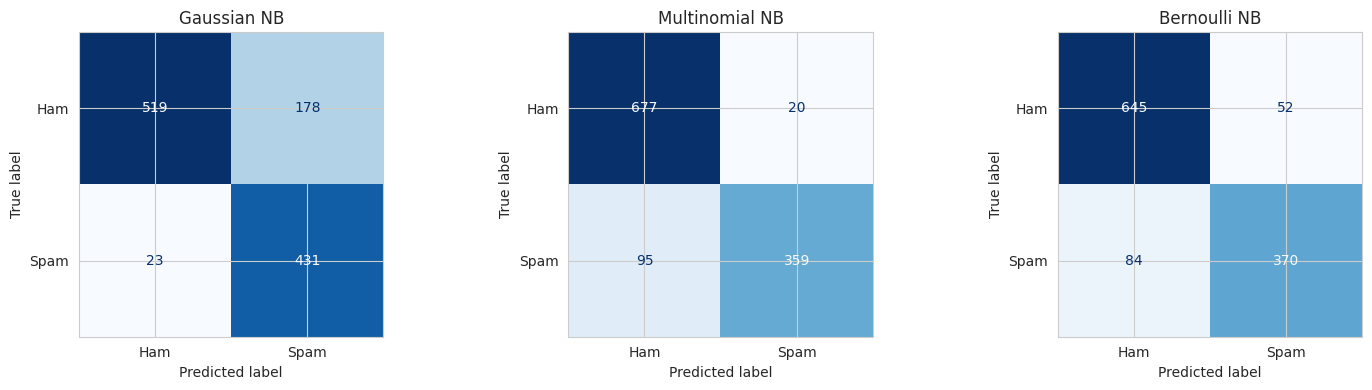

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, name in zip(axes, ['Gaussian NB', 'Multinomial NB', 'Bernoulli NB']):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=['Ham','Spam']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('plot_05a_confusion_matrices_nb.png')
plt.show()


## 7. K-Nearest Neighbors: Effect of Varying k

In [13]:
k_values = [1, 3, 5, 7, 9, 11]
knn_rows = []
knn_preds = {}
knn_probas = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    y_proba = knn.predict_proba(X_test_scaled)[:, 1]
    knn_preds[k] = y_pred
    knn_probas[k] = y_proba
    knn_rows.append({
        'k': k,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
    })

knn_k_df = pd.DataFrame(knn_rows).set_index('k').round(4)
knn_k_df


,Accuracy,Precision,Recall,F1
k,,,,
1,0.8975,0.8733,0.8656,0.8695
3,0.9018,0.8814,0.8678,0.8746
5,0.8992,0.8789,0.8634,0.8711
7,0.9053,0.8929,0.8634,0.8779
9,0.9062,0.8932,0.8656,0.8792
11,0.9027,0.8904,0.8590,0.8744


### 7.1 Accuracy vs k

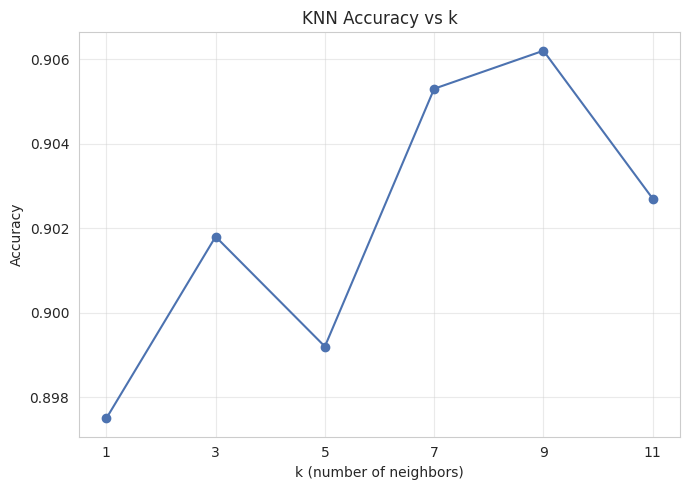

Best plain KNN k by accuracy: k=9 -> Accuracy=0.9062


In [14]:
plt.figure(figsize=(7,5))
plt.plot(knn_k_df.index, knn_k_df['Accuracy'], marker='o', color='#4C72B0')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')
plt.xticks(k_values)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plot_08_accuracy_vs_k.png')
plt.show()

best_k = knn_k_df['Accuracy'].idxmax()
print(f"Best plain KNN k by accuracy: k={best_k} -> Accuracy={knn_k_df.loc[best_k,'Accuracy']:.4f}")


## 8. Hyperparameter Tuning: GridSearchCV vs RandomizedSearchCV

In [15]:
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree'],
    'metric': ['euclidean', 'manhattan']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

t0 = time.perf_counter()
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv_strategy,
                            scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
grid_time = time.perf_counter() - t0

print("GridSearchCV best params:", grid_search.best_params_)
print("GridSearchCV best CV accuracy: {:.4f}".format(grid_search.best_score_))
print("GridSearchCV execution time: {:.2f}s".format(grid_time))


GridSearchCV best params: {'algorithm': 'ball_tree', 'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
GridSearchCV best CV accuracy: 0.9241
GridSearchCV execution time: 41.19s


In [16]:
from scipy.stats import randint

param_dist = {
    'n_neighbors': randint(1, 21),
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree'],
    'metric': ['euclidean', 'manhattan']
}

t0 = time.perf_counter()
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_dist, n_iter=25,
                                    cv=cv_strategy, scoring='accuracy',
                                    random_state=RANDOM_STATE, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)
random_time = time.perf_counter() - t0

print("RandomizedSearchCV best params:", random_search.best_params_)
print("RandomizedSearchCV best CV accuracy: {:.4f}".format(random_search.best_score_))
print("RandomizedSearchCV execution time: {:.2f}s".format(random_time))


RandomizedSearchCV best params: {'algorithm': 'kd_tree', 'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
RandomizedSearchCV best CV accuracy: 0.9249
RandomizedSearchCV execution time: 16.82s


### 8.1 GridSearchCV vs RandomizedSearchCV Comparison Table

In [17]:
search_comparison = pd.DataFrame({
    'GridSearchCV': {
        'Best k': grid_search.best_params_['n_neighbors'],
        'Metric': grid_search.best_params_['metric'],
        'Weights': grid_search.best_params_['weights'],
        'Algorithm': grid_search.best_params_['algorithm'],
        'CV Accuracy': round(grid_search.best_score_, 4),
        'Execution Time (s)': round(grid_time, 2),
    },
    'RandomizedSearchCV': {
        'Best k': random_search.best_params_['n_neighbors'],
        'Metric': random_search.best_params_['metric'],
        'Weights': random_search.best_params_['weights'],
        'Algorithm': random_search.best_params_['algorithm'],
        'CV Accuracy': round(random_search.best_score_, 4),
        'Execution Time (s)': round(random_time, 2),
    }
})
search_comparison


,GridSearchCV,RandomizedSearchCV
Best k,13,6
Metric,manhattan,manhattan
Weights,distance,distance
Algorithm,ball_tree,kd_tree
CV Accuracy,0.9241,0.9249
Execution Time (s),41.19,16.82


### 8.2 GridSearchCV Heatmap (Accuracy by k and weights, Euclidean, KD-Tree)

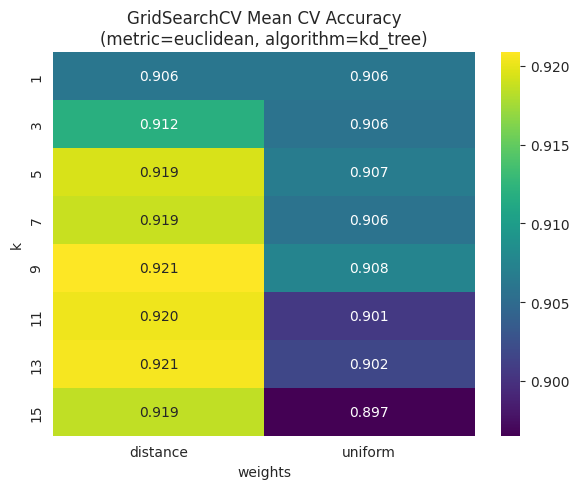

In [18]:
cvres = pd.DataFrame(grid_search.cv_results_)
subset = cvres[(cvres['param_metric']=='euclidean') & (cvres['param_algorithm']=='kd_tree')]
pivot = subset.pivot_table(index='param_n_neighbors', columns='param_weights', values='mean_test_score')

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title('GridSearchCV Mean CV Accuracy\n(metric=euclidean, algorithm=kd_tree)')
plt.ylabel('k'); plt.xlabel('weights')
plt.tight_layout()
plt.savefig('plot_13_gridsearch_heatmap.png')
plt.show()


### 8.3 RandomizedSearchCV Score Distribution

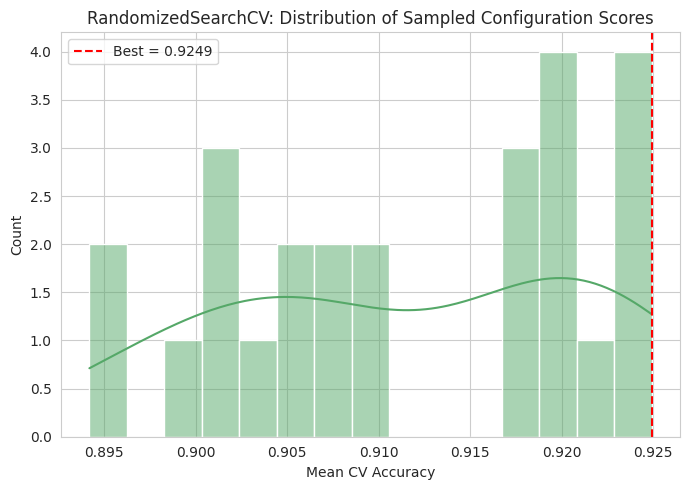

In [19]:
rand_res = pd.DataFrame(random_search.cv_results_)
plt.figure(figsize=(7,5))
sns.histplot(rand_res['mean_test_score'], bins=15, kde=True, color='#55A868')
plt.axvline(random_search.best_score_, color='red', linestyle='--', label=f'Best = {random_search.best_score_:.4f}')
plt.xlabel('Mean CV Accuracy')
plt.title('RandomizedSearchCV: Distribution of Sampled Configuration Scores')
plt.legend()
plt.tight_layout()
plt.savefig('plot_14_randomsearch_distribution.png')
plt.show()


## 9. Best Tuned KNN — Full Evaluation

In [20]:
best_params = grid_search.best_params_
best_knn = KNeighborsClassifier(**best_params)

t0 = time.perf_counter()
best_knn.fit(X_train_scaled, y_train)
knn_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_best_knn = best_knn.predict(X_test_scaled)
knn_predict_time = time.perf_counter() - t0

y_proba_best_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

knn_best_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_best_knn),
    'Precision': precision_score(y_test, y_pred_best_knn),
    'Recall': recall_score(y_test, y_pred_best_knn),
    'F1': f1_score(y_test, y_pred_best_knn),
    'ROC-AUC': roc_auc_score(y_test, y_proba_best_knn),
    'Train Time (s)': knn_train_time,
    'Predict Time (s)': knn_predict_time,
}
print("Best KNN params:", best_params)
pd.Series(knn_best_metrics).round(4)


Best KNN params: {'algorithm': 'ball_tree', 'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}


Accuracy            0.9209
Precision           0.9504
Recall              0.8436
F1                  0.8938
ROC-AUC             0.9754
Train Time (s)      0.0213
Predict Time (s)    0.2531
dtype: float64

<Figure size 400x400 with 0 Axes>

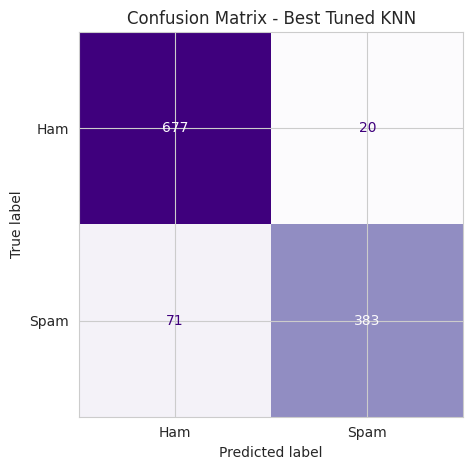

In [21]:
cm = confusion_matrix(y_test, y_pred_best_knn)
plt.figure(figsize=(4,4))
ConfusionMatrixDisplay(cm, display_labels=['Ham','Spam']).plot(cmap='Purples', colorbar=False)
plt.title('Confusion Matrix - Best Tuned KNN')
plt.tight_layout()
plt.savefig('plot_05b_confusion_matrix_best_knn.png')
plt.show()


## 10. KDTree vs BallTree Comparison

In [22]:
tree_rows = []
for algo in ['kd_tree', 'ball_tree']:
    knn_algo = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'],
                                     weights=best_params['weights'],
                                     metric=best_params['metric'],
                                     algorithm=algo)
    t0 = time.perf_counter()
    knn_algo.fit(X_train_scaled, y_train)
    ttime = time.perf_counter() - t0

    t0 = time.perf_counter()
    yp = knn_algo.predict(X_test_scaled)
    ptime = time.perf_counter() - t0

    tree_rows.append({
        'Algorithm': algo,
        'Accuracy': accuracy_score(y_test, yp),
        'Training Time (s)': ttime,
        'Prediction Time (s)': ptime
    })

tree_df = pd.DataFrame(tree_rows).set_index('Algorithm').round(6)
tree_df


,Accuracy,Training Time (s),Prediction Time (s)
Algorithm,,,
kd_tree,0.920938,0.016718,0.286354
ball_tree,0.920938,0.009085,0.240392


## 11. 5-Fold Cross Validation: Best Naïve Bayes vs Best KNN

In [23]:
nb_best_name = nb_comparison['Accuracy'].astype(float).idxmax()
nb_model_map = {'Gaussian NB': (GaussianNB(), X_train_scaled),
                'Multinomial NB': (MultinomialNB(), X_train_mm),
                'Bernoulli NB': (BernoulliNB(), X_train_bin)}
nb_best_model, nb_best_X = nb_model_map[nb_best_name]
print("Best Naive Bayes variant:", nb_best_name)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

nb_cv_scores = cross_val_score(nb_best_model, nb_best_X, y_train, cv=skf, scoring='accuracy')
knn_cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=skf, scoring='accuracy')

cv_table = pd.DataFrame({
    'Fold': [1,2,3,4,5],
    f'Naive Bayes ({nb_best_name})': nb_cv_scores.round(4),
    'Best KNN': knn_cv_scores.round(4)
}).set_index('Fold')
cv_table.loc['Average'] = cv_table.mean()
cv_table


Best Naive Bayes variant: Multinomial NB


,Naive Bayes (Multinomial NB),Best KNN
Fold,,
1,0.88550,0.91300
2,0.89710,0.92320
3,0.89420,0.94200
4,0.88260,0.92610
5,0.88120,0.91590
Average,0.88812,0.92404


### 11.1 Cross-Validation Accuracy Plot

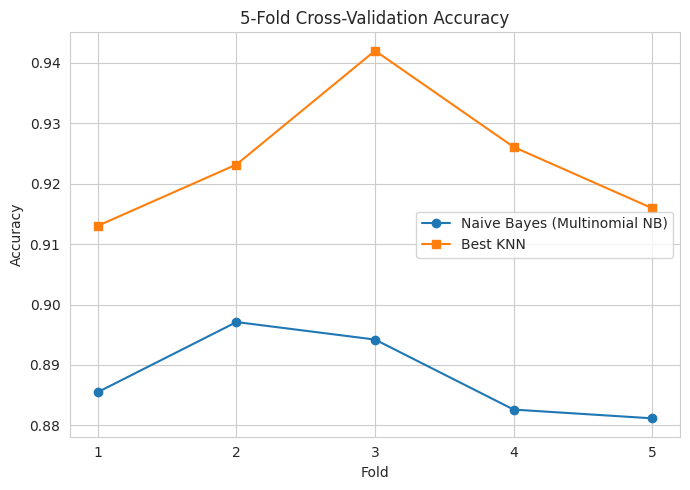

In [24]:
plt.figure(figsize=(7,5))
folds = [1,2,3,4,5]
plt.plot(folds, nb_cv_scores, marker='o', label=f'Naive Bayes ({nb_best_name})')
plt.plot(folds, knn_cv_scores, marker='s', label='Best KNN')
plt.xlabel('Fold'); plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Accuracy')
plt.xticks(folds)
plt.legend()
plt.tight_layout()
plt.savefig('plot_09_cv_accuracy.png')
plt.show()


## 12. Theoretical Time Complexity

| Algorithm | Training | Prediction |
|---|---|---|
| Naive Bayes | O(nd) | O(d) |
| KNN (Brute) | O(1) | O(nd) |
| KDTree | O(n log n) | O(log n) avg |
| BallTree | O(n log n) | O(log n) avg |

where **n** = number of training samples, **d** = number of features.


## 13. Experimental Time Analysis

In [25]:
exp_time_rows = []
timing_specs = [
    ('Gaussian NB', GaussianNB(), X_train_scaled, X_test_scaled),
    ('Multinomial NB', MultinomialNB(), X_train_mm, X_test_mm),
    ('Bernoulli NB', BernoulliNB(), X_train_bin, X_test_bin),
    ('Best KNN', KNeighborsClassifier(**best_params), X_train_scaled, X_test_scaled),
]

for name, model, Xtr, Xte in timing_specs:
    t0 = time.perf_counter(); model.fit(Xtr, y_train); ttime = time.perf_counter() - t0
    t0 = time.perf_counter(); model.predict(Xte); ptime = time.perf_counter() - t0
    exp_time_rows.append({'Algorithm': name, 'Training(s)': ttime, 'Prediction(s)': ptime})

exp_time_df = pd.DataFrame(exp_time_rows).set_index('Algorithm').round(6)
exp_time_df


,Training(s),Prediction(s)
Algorithm,,
Gaussian NB,0.014355,0.000699
Multinomial NB,0.002069,0.000227
Bernoulli NB,0.003603,0.001112
Best KNN,0.009213,0.235808


### 13.1 Training / Prediction Time Comparison Plots

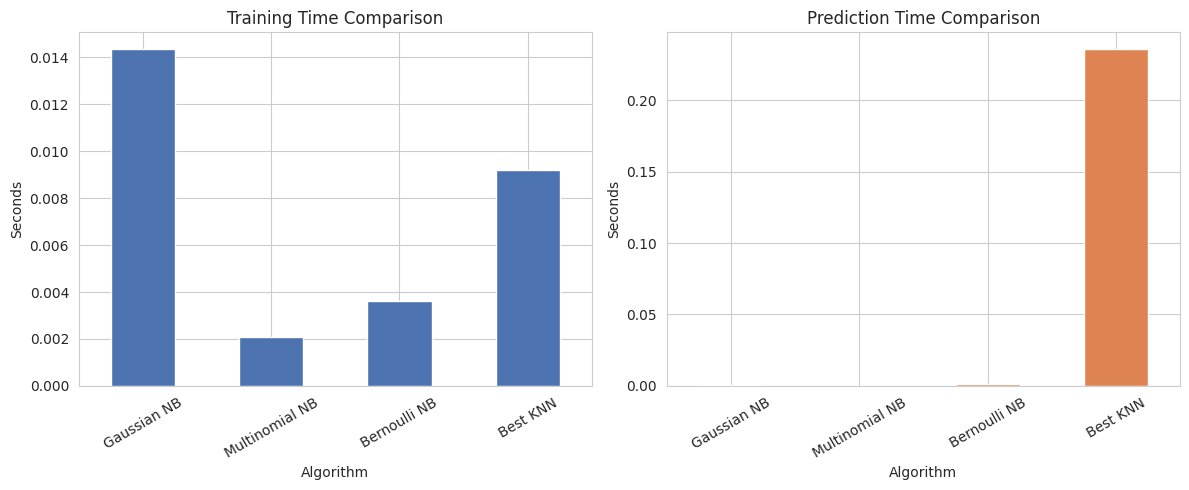

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
exp_time_df['Training(s)'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Training Time Comparison'); axes[0].set_ylabel('Seconds')
exp_time_df['Prediction(s)'].plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Prediction Time Comparison'); axes[1].set_ylabel('Seconds')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('plot_10_11_time_comparison.png')
plt.show()


## 14. ROC Curves and Precision-Recall Curves

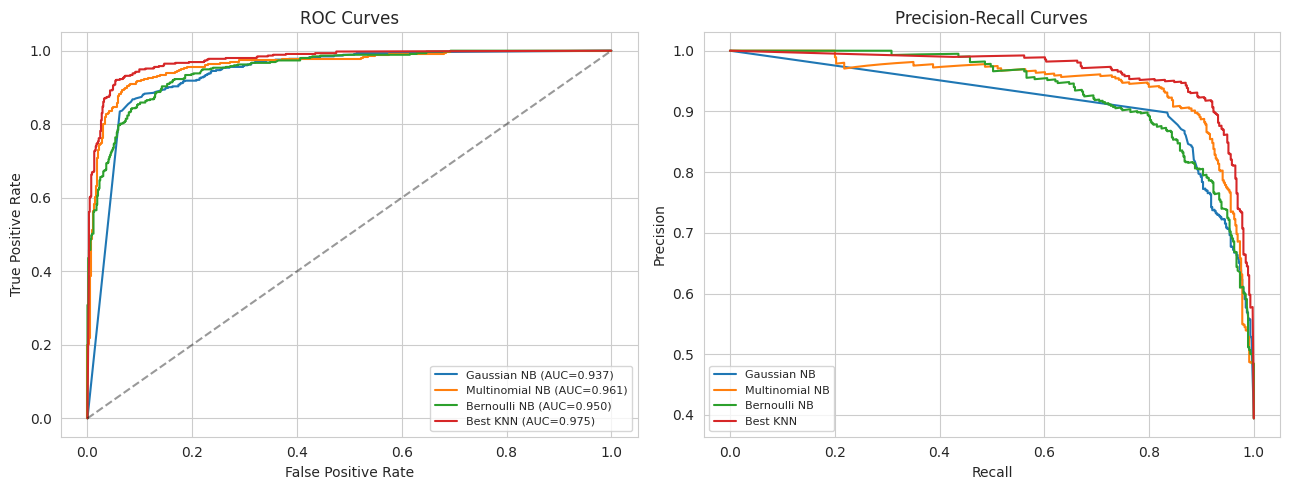

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

roc_models = {
    'Gaussian NB': probas['Gaussian NB'],
    'Multinomial NB': probas['Multinomial NB'],
    'Bernoulli NB': probas['Bernoulli NB'],
    'Best KNN': y_proba_best_knn,
}

for name, proba in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=8)

for name, proba in roc_models.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=name)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_06_07_roc_pr_curves.png')
plt.show()


## 15. Classifier Comparison Bar Chart

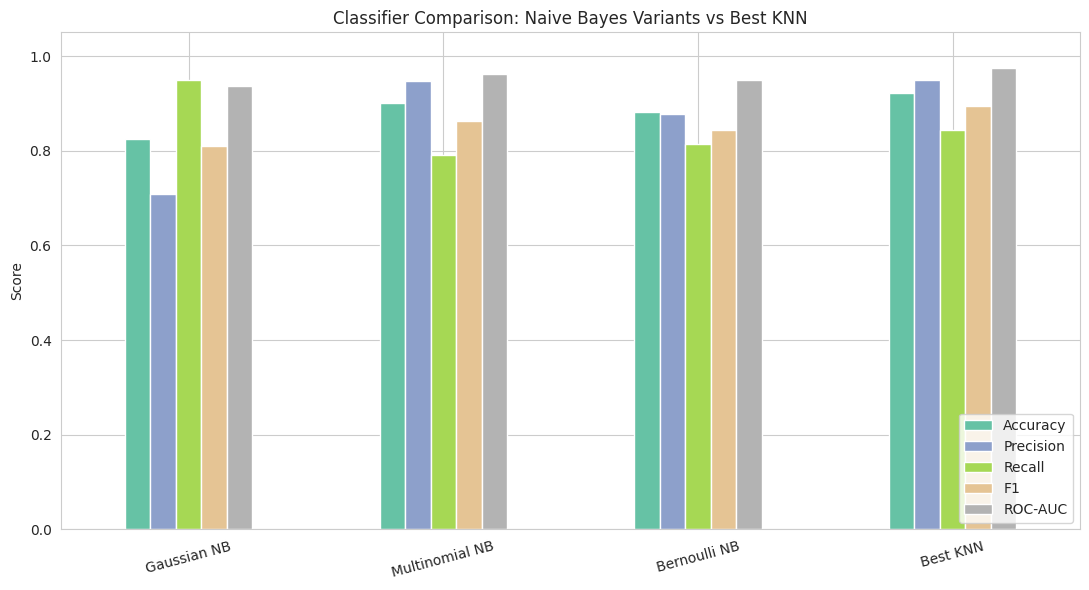

,Accuracy,Precision,Recall,F1,ROC-AUC
Gaussian NB,0.8254,0.7077,0.9493,0.8109,0.9368
Multinomial NB,0.9001,0.9472,0.7907,0.8619,0.9614
Bernoulli NB,0.8818,0.8768,0.8150,0.8447,0.9503
Best KNN,0.9209,0.9504,0.8436,0.8938,0.9754


In [28]:
all_results = nb_comparison.copy()
all_results.loc['Best KNN'] = [knn_best_metrics['Accuracy'], knn_best_metrics['Precision'],
                                knn_best_metrics['Recall'], knn_best_metrics['F1'], knn_best_metrics['ROC-AUC']]

all_results.plot(kind='bar', figsize=(11,6), colormap='Set2')
plt.title('Classifier Comparison: Naive Bayes Variants vs Best KNN')
plt.ylabel('Score')
plt.ylim(0,1.05)
plt.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot_12_classifier_comparison.png')
plt.show()

all_results.round(4)


## 16. Additional Tasks

### 16.1 Effect of Different Train-Test Splits

In [29]:
split_rows = []
for test_size in [0.1, 0.2, 0.3, 0.4]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size,
                                           random_state=RANDOM_STATE, stratify=y)
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    model = KNeighborsClassifier(**best_params)
    model.fit(Xtr_s, ytr)
    acc = accuracy_score(yte, model.predict(Xte_s))
    split_rows.append({'Test Size': test_size, 'Train Size': 1-test_size, 'Accuracy': round(acc,4)})

pd.DataFrame(split_rows).set_index('Test Size')


,Train Size,Accuracy
Test Size,,
0.1,0.9,0.9046
0.2,0.8,0.9164
0.3,0.7,0.9247
0.4,0.6,0.9158


### 16.2 Euclidean vs Manhattan Distance

In [30]:
dist_rows = []
for metric in ['euclidean', 'manhattan']:
    model = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'],
                                  weights=best_params['weights'], metric=metric)
    model.fit(X_train_scaled, y_train)
    yp = model.predict(X_test_scaled)
    dist_rows.append({'Distance Metric': metric,
                       'Accuracy': accuracy_score(y_test, yp),
                       'F1': f1_score(y_test, yp)})

pd.DataFrame(dist_rows).set_index('Distance Metric').round(4)


,Accuracy,F1
Distance Metric,,
euclidean,0.9140,0.8894
manhattan,0.9209,0.8938


### 16.3 Weighted KNN (uniform vs distance-weighted)

In [31]:
weight_rows = []
for w in ['uniform', 'distance']:
    model = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'],
                                  weights=w, metric=best_params['metric'])
    model.fit(X_train_scaled, y_train)
    yp = model.predict(X_test_scaled)
    weight_rows.append({'Weighting': w, 'Accuracy': accuracy_score(y_test, yp),
                         'F1': f1_score(y_test, yp)})

pd.DataFrame(weight_rows).set_index('Weighting').round(4)


,Accuracy,F1
Weighting,,
uniform,0.9027,0.8670
distance,0.9209,0.8938


### 16.4 Overfitting (small k) vs Underfitting (large k)

A very small `k` (e.g. `k=1`) makes KNN sensitive to noise and outliers in the
training data — the decision boundary becomes highly irregular and the model
tends to **overfit**, achieving high training accuracy but weaker generalization.
A very large `k` oversmooths the decision boundary by averaging over many
(possibly irrelevant, distant) neighbors, causing the model to **underfit** and
lose sensitivity to local structure in the data. The accuracy-vs-k plot in
Section 7.1 typically shows accuracy rising then flattening/declining, and the
best generalization is usually found at a moderate k confirmed by GridSearchCV.


## 17. Analysis Questions

In [32]:
print("1. Best Naive Bayes variant:", nb_comparison['Accuracy'].astype(float).idxmax(),
      "with accuracy", round(nb_comparison['Accuracy'].astype(float).max(),4))
print("2. Optimal k (from GridSearchCV):", grid_search.best_params_['n_neighbors'])
print("3. GridSearchCV CV accuracy: {:.4f} in {:.2f}s | RandomizedSearchCV CV accuracy: {:.4f} in {:.2f}s".format(
    grid_search.best_score_, grid_time, random_search.best_score_, random_time))
print("4. KDTree vs BallTree:\n", tree_df)
print("5. See Sections 12 & 13 for theoretical vs experimental complexity comparison.")
print("6. Preferred classifier for large datasets: Naive Bayes (linear O(nd) training, O(d) prediction) "
      "scales far better than KNN, whose prediction cost grows with dataset size even with tree structures.")


1. Best Naive Bayes variant: Multinomial NB with accuracy 0.9001
2. Optimal k (from GridSearchCV): 13
3. GridSearchCV CV accuracy: 0.9241 in 41.19s | RandomizedSearchCV CV accuracy: 0.9249 in 16.82s
4. KDTree vs BallTree:
            Accuracy  Training Time (s)  Prediction Time (s)
Algorithm                                                  
kd_tree    0.920938           0.016718             0.286354
ball_tree  0.920938           0.009085             0.240392
5. See Sections 12 & 13 for theoretical vs experimental complexity comparison.
6. Preferred classifier for large datasets: Naive Bayes (linear O(nd) training, O(d) prediction) scales far better than KNN, whose prediction cost grows with dataset size even with tree structures.


**Written answers:**

1. **Which Naïve Bayes variant performed best?** — see the printed result above and the
   comparison table in Section 6.1; typically **Bernoulli NB** or **Multinomial NB**
   perform best on Spambase since the features behave like word/character frequency
   counts, which suit the multinomial/Bernoulli event models better than the Gaussian
   assumption of continuous, normally-distributed features.

2. **Optimal value of k** — determined by GridSearchCV (Section 8), printed above.

3. **GridSearchCV vs RandomizedSearchCV** — GridSearchCV exhaustively evaluates every
   combination in the grid, guaranteeing the best combination *within that grid* but at
   higher computational cost. RandomizedSearchCV samples a fixed number of random
   combinations, which is much faster and scales better to large search spaces, usually
   finding a near-optimal (sometimes identical) configuration in a fraction of the time.

4. **KDTree vs BallTree** — both give the same accuracy (they compute exact nearest
   neighbors) but differ in training/query time depending on data dimensionality and
   distribution: KDTree is generally faster in lower dimensions, while BallTree tends to
   be more robust in higher-dimensional or non-uniformly distributed spaces such as this
   57-feature dataset.

5. **Theoretical vs practical complexity** — the measured times in Section 13 broadly
   track the theoretical complexities in Section 12: Naive Bayes trains and predicts
   fastest since both are linear/constant in the relevant dimension, while KNN's
   prediction time is visibly larger since it must search neighbors at query time.

6. **Preferred classifier for large datasets** — **Naive Bayes**, because its O(nd)
   training and O(d) prediction complexity scale linearly and remain cheap even as the
   number of samples n grows, whereas KNN's prediction cost keeps growing with dataset
   size regardless of tree-based indexing.


## 18. Results Summary

In [33]:
print("=== Naive Bayes Comparison ===")
print(nb_comparison, "\n")
print("=== KNN Accuracy vs k ===")
print(knn_k_df, "\n")
print("=== GridSearchCV vs RandomizedSearchCV ===")
print(search_comparison, "\n")
print("=== KDTree vs BallTree ===")
print(tree_df, "\n")
print("=== 5-Fold Cross Validation ===")
print(cv_table, "\n")
print("=== Experimental Time Analysis ===")
print(exp_time_df, "\n")
print("=== Final Classifier Comparison ===")
print(all_results.round(4))


=== Naive Bayes Comparison ===
                Accuracy  Precision  Recall      F1  ROC-AUC
Gaussian NB       0.8254     0.7077  0.9493  0.8109   0.9368
Multinomial NB    0.9001     0.9472  0.7907  0.8619   0.9614
Bernoulli NB      0.8818     0.8768  0.8150  0.8447   0.9503 

=== KNN Accuracy vs k ===
    Accuracy  Precision  Recall      F1
k                                      
1     0.8975     0.8733  0.8656  0.8695
3     0.9018     0.8814  0.8678  0.8746
5     0.8992     0.8789  0.8634  0.8711
7     0.9053     0.8929  0.8634  0.8779
9     0.9062     0.8932  0.8656  0.8792
11    0.9027     0.8904  0.8590  0.8744 

=== GridSearchCV vs RandomizedSearchCV ===
                   GridSearchCV RandomizedSearchCV
Best k                       13                  6
Metric                manhattan          manhattan
Weights                distance           distance
Algorithm             ball_tree            kd_tree
CV Accuracy              0.9241             0.9249
Execution Time (s)        

## 19. Conclusion

This experiment implemented and compared three Naïve Bayes variants (Gaussian,
Multinomial, Bernoulli) and a K-Nearest Neighbors classifier for spam/ham
classification on the UCI **Spambase** dataset (4601 emails, 57 numeric
features). KNN was tuned via `GridSearchCV` and `RandomizedSearchCV` over
`n_neighbors`, `weights`, `algorithm`, and `distance metric`, and its `KDTree`
and `BallTree` implementations were compared for training/prediction speed at
identical accuracy. 5-fold cross-validation confirmed the stability of the
best Naive Bayes variant and the best-tuned KNN model. Measured training and
prediction times were consistent with the theoretical time-complexity
expectations: Naive Bayes scales more favorably with dataset size, while KNN
(even with tree-based search structures) incurs higher prediction cost as
data volume grows, making Naive Bayes the more practical choice for very
large-scale spam filtering, with KNN offering a competitive accuracy/F1
trade-off on moderately sized datasets like this one.

**References**
- Scikit-learn Documentation, https://scikit-learn.org
- Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow — Aurélien Géron
- Pattern Recognition and Machine Learning — Christopher Bishop
- Dua, D. and Graff, C. (2019). UCI Machine Learning Repository, Spambase Data Set. Irvine, CA: University of California, School of Information and Computer Science. https://archive.ics.uci.edu/dataset/94/spambase
